In [1]:

import os
import sys
import argparse
import datetime
import numpy as np
import time
import torch
import torch.backends.cudnn as cudnn
import json
from pathlib import Path
from collections import OrderedDict
from functools import partial

# Add project root to path
# sys.path.insert(0, str(Path(__file__).parent))

from timm.models import create_model
from timm.loss import LabelSmoothingCrossEntropy, SoftTargetCrossEntropy
from timm.scheduler import create_scheduler
from src.optim.optim_factory import create_optimizer, get_parameter_groups, LayerDecayValueAssigner

from timm.utils import ModelEma

from src.utils.config import get_cfg, merge_config_file, freeze_cfg, load_and_freeze_config
from src.engine.train_engine import TrainingEngine
from src.engine.val_engine import ValidationEngine
from src.utils.evaluation import merge_distributed_results
from src.optim.mixup import Mixup
# from src.optim.optim_factory import LayerDecayValueAssigner
from src.dataset.datasets import build_dataset
from src.utils.utils import NativeScalerWithGradNormCount as NativeScaler
from src.utils.utils import multiple_samples_collate
from src.utils.logger import TensorboardLogger
from src.utils import utils

from src.models import ViT, ViT_pretrain, layers

from run_finetuning_with_yacs import create_data_loaders, create_model_from_config

/root/miniconda3/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
config_path = 'configs/gaze360T.yaml'
cfg = get_cfg()
merge_config_file(cfg, config_path)
cfg.SYSTEM.DISTRIBUTED = False  # Disable distributed training
cfg.batch_size = 2  # Set batch size to 2

In [3]:
data_loader_train, data_loader_val = create_data_loaders()
model = create_model_from_config()

Found 239 CSV files in saved/data/gaze360T/train
Loaded 239 CSV files with 13233 valid clips
Number of the class = 2
Found 25 CSV files in saved/data/gaze360T/val
Loaded 25 CSV files with 1026 valid clips
Number of the class = 2
==> Note: Use 'local_global' for compute reduction (lg_region_size=[2, 2, 10],lg_first_attn_type=self, lg_third_attn_type=cross,lg_attn_param_sharing_first_third=False,lg_attn_param_sharing_all=False,lg_classify_token_type=org,lg_no_second=False, lg_no_third=False)
==> Number of local regions: 20 (size=[4, 5, 1])
model after create_model = VisionTransformer(
  (patch_embed): PatchEmbed(
    (proj): Conv3d(3, 512, kernel_size=(2, 16, 16), stride=(2, 16, 16))
  )
  (pos_drop): Dropout(p=0.0, inplace=False)
  (blocks): ModuleList(
    (0): LGBlock(
      (first_attn_norm0): LayerNorm((512,), eps=1e-06, elementwise_affine=True)
      (first_attn): GeneralAttention(
        (q): Linear(in_features=512, out_features=512, bias=False)
        (kv): Linear(in_features=5

In [5]:
model_path = "/home/qzk/Facial-Foundation-Model/gaze360_7_28/checkpoint-best.pth"
state_dict = torch.load(model_path, map_location='cpu', weights_only=False)
state_dict = state_dict["model"]
state_dict = {k.replace("module.", ""): v for k, v in state_dict.items()}
model.load_state_dict(state_dict)

<All keys matched successfully>

In [4]:
# pick a sample from the training set
samples, targets, _, _ = next(iter(data_loader_train))
print(samples.shape, targets.shape)
# samples, targets, _ = next(iter(data_loader_val))
# print("sample likely contains:", sample.keys())
# visualize the model output for the sample
# with torch.no_grad():
#     model.eval()
#     print("shape of sample:", samples.shape)
#     output = model(samples)
#     if targets.shape[1] == 3:
#         from src.utils.gaze import gaze3d_to_gaze2d
#         targets = gaze3d_to_gaze2d(targets)
#     print("output ", output)
#     print("target", targets)



torch.Size([16, 3, 16, 160, 160]) torch.Size([16, 16, 3])


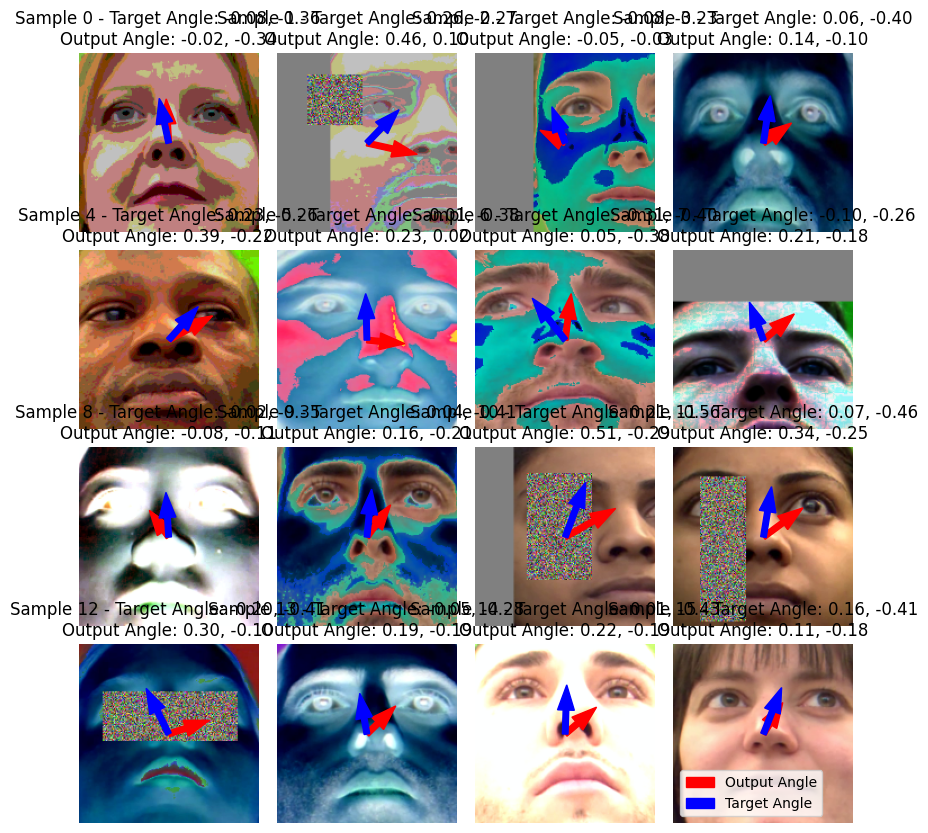

angular error:  17.619869232177734


In [16]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

def pitchyaw_to_vector(a):
    if a.shape[1] == 2:
        sin = torch.sin(a)
        cos = torch.cos(a)
        return torch.stack([cos[:, 0] * sin[:, 1], sin[:, 0], cos[:, 0] * cos[:, 1]], dim=1)
    elif a.shape[1] == 3:
        return F.normalize(a)
    else:
        raise ValueError('Do not know how to convert tensor of size %s' % a.shape)

# draw 16 samples in a single figure
plt.figure(figsize=(10, 10))
plt.subplots_adjust(wspace=0.1, hspace=0.1)

for i, sample in enumerate(samples):
    if i >= 16:
        break
    img_to_show = sample[:,-1, ...]  # Assuming the last channel is the image
    img_to_show = img_to_show.permute(1, 2, 0).numpy()  # Convert to HWC format
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img_to_show = img_to_show * std + mean  # Denormalize
    img_to_show = np.clip(img_to_show, 0, 1)  # Clip values to [0, 1]
    img_to_show = (img_to_show * 255).astype(np.uint8)  # Convert to uint8 for display
    
    plt.subplot(4, 4, i + 1)
    plt.imshow(img_to_show)
    
    # Show the target and output angles
    target_angle = targets[i].numpy()
    output_angle = output[i].numpy()
    
    pl0 = -np.cos(output_angle[0]) * np.sin(output_angle[1])
    pl1 = -np.sin(output_angle[0])
    
    plt.arrow(80, 80, pl0 * 50, pl1 * 50, width=5, color='red', label='Output Angle')
    
    ol0 = -np.cos(target_angle[0]) * np.sin(target_angle[1])
    ol1 = -np.sin(target_angle[0])
    
    plt.arrow(80, 80, ol0 * 50, ol1 * 50, width=5, color='blue', label='Target Angle')
    plt.title(f'Sample {i} - Target Angle: {ol0:.2f}, {ol1:.2f}\nOutput Angle: {pl0:.2f}, {pl1:.2f}')
    plt.axis('off')
plt.legend()
plt.show()
    

# for i, sample in enumerate(samples):
#     if i >=16 :
#         break
#     img_to_show = sample[:,-1,...]
#     img_to_show = img_to_show.permute(1, 2, 0).numpy()  # Convert to HWC format
#     mean = np.array([0.485, 0.456, 0.406])
#     std = np.array([0.229, 0.224, 0.225])
#     img_to_show = img_to_show * std + mean  # Denormalize
#     img_to_show = np.clip(img_to_show, 0, 1)  #
#     img_to_show = (img_to_show * 255).astype(np.uint8)  # Convert to uint8 for display
#     plt.imshow(img_to_show)
#     # show the target and output angles
#     target_angle = targets[i].numpy()
#     output_angle = output[i].numpy()
#     # plt.squiv
#     pl0 = -np.cos(output_angle[0]) * np.sin(output_angle[1])
#     pl1 = -np.sin(output_angle[0])
    
    
#     # pl0 = output_angle[0]
#     # pl1 = output_angle[1]
#     # plt.Arrow(80, 80, pl0 * 500, pl1 * 500, width=50, color='red', label='Output Angle')
#     plt.arrow(80, 80, pl0 * 50, pl1 * 50, width=5, color='red', label='Output Angle')
#     ol0 = -np.cos(target_angle[0]) * np.sin(target_angle[1])
#     ol1 = -np.sin(target_angle[0])
#     # ol0 = target_angle[0]
#     # ol1 = target_angle[1]
#     plt.arrow(80, 80, ol0 * 50, ol1 * 50, width=5, color='blue', label='Target Angle')
#     # plt.title(f'Sample {i} - Target Angle: {pl0} {pl1}, Output Angle: {ol0} {ol1}')
#     plt.show()
    
pred_vecs = pitchyaw_to_vector(output)
target_vecs = pitchyaw_to_vector(targets)
sim = F.cosine_similarity(pred_vecs, target_vecs, dim=1, eps=1e-8)
sim = F.hardtanh_(sim, min_val=-1+1e-8, max_val=1-1e-8)
angular_err = torch.acos(sim) * 180. / np.pi
print("angular error: ", angular_err.mean().item())
    

In [21]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

# if target_angle.shape[1] == 3:
#     from src.utils.gaze import gaze3d_to_gaze2d
#     target_angle = gaze3d_to_gaze2d(target_angle)

for i, sample in enumerate(samples):
    print("sample shape:", sample.shape) # (3, 16, 160, 160)
    # record to a video file
    sample = sample.permute(1, 2, 3, 0)  # Change to (time, height, width, channels)
    sample = sample.detach().cpu().numpy()  # Convert to numpy array
    # add mean and std normalization
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    sample = (sample * std + mean)  # Denormalize
    sample = np.clip(sample, 0, 1)  # Clip values to [0, 1]
    sample = (sample * 255).astype(np.uint8)  # Convert to uint8
    lbl = targets[i]
    if lbl.shape[1] == 3:
        from src.utils.gaze import gaze3d_to_gaze2d
        # print(lbl)
        lbl = gaze3d_to_gaze2d(lbl)
    new_samples = []
    for j in range(sample.shape[0]):
        # Draw the target and output angles on each frame
        target_angle = lbl[j].numpy()
        # output_angle = output[i].numpy()
        
        # pl0 = -np.cos(output_angle[0]) * np.sin(output_angle[1])
        # pl1 = -np.sin(output_angle[0])
        
        # cv2.arrowedLine(sample[j], (80, 80), (int(80 + pl0 * 50), int(80 + pl1 * 50)), (0, 0, 255), 2, tipLength=0.1)
        
        ol0 = -np.cos(target_angle[0]) * np.sin(target_angle[1])
        ol1 = -np.sin(target_angle[0])
        
        # print(sample[j].shape, target_angle.shape)
        # print("type of sample[j]:", type(sample[j]))
        
        new_sample = cv2.arrowedLine(sample[j].copy(), (80, 80), (int(80 + ol0 * 50), int(80 + ol1 * 50)), (255, 0, 0), 2, tipLength=0.1)
        new_samples.append(new_sample)
        
    new_samples = np.array(new_samples)
    sample = new_samples  # Use the modified samples with arrows
        # cv2.arrowedLine(sample[j], (80, 80), (int(80 + ol0 * 50), int(80 + ol1 * 50)), (255, 0, 0), 2, tipLength=0.1)
    # sample = cv2.cvtColor(sample, cv2.COLOR_RGB2BGR)
    # record a video file
    video_path = f"output/data_debug/sample_video_{i}.mp4"
    
    fourcc = cv2.VideoWriter_fourcc(*'mp4v')
    height, width, _ = sample[0].shape
    out = cv2.VideoWriter(video_path, fourcc, 30.0, (width, height))
    for frame in sample:
        out.write(frame)
    out.release()
    print("video saved to:", video_path)

sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_0.mp4
sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_1.mp4
sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_2.mp4
sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_3.mp4
sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_4.mp4
sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_5.mp4
sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_6.mp4
sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_7.mp4
sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_8.mp4
sample shape: torch.Size([3, 16, 160, 160])
video saved to: output/data_debug/sample_video_9.mp4
sample shape: torch.Size([3, 1